# 07 · SpliceAI — predicting splice-disruption effects

Notebooks **02–06** scored *missense* variants — changes that swap one amino acid
for another. But a huge fraction of CFTR disease alleles never touch an amino acid
at all. They live **deep in introns** or are **synonymous** (they change the DNA
but not the protein), and they cause disease by **breaking how the gene is spliced**.

Missense tools (AlphaMissense, EVE, ESM1b, REVEL, PrimateAI) are **completely blind**
to these variants — there is no amino-acid change for them to score. To catch them
you need a different kind of tool: a **splice predictor**.

---

### Why splicing matters for CFTR

Before a gene becomes protein, its RNA is *spliced*: introns are cut out and exons
are stitched together. The cell finds the cut points using short sequence signals —
a **donor site** at the start of an intron and an **acceptor site** at its end. A
single base change can:

- **destroy** a real splice site → an exon gets skipped or an intron kept, and
- **create** a brand-new ("cryptic") splice site → a chunk of intron sneaks into the
  mRNA, usually shifting the reading frame and truncating the protein.

Either way the CFTR protein is wrecked, even though the variant is nowhere near the
coding sequence. Famous real CFTR examples you'll meet in this notebook:

| Legacy name | HGVS (c.) | What it does |
|---|---|---|
| **3849+10kb C>T** | `c.3718-2477C>T` | deep intronic — 2,477 nt before the next exon; creates a *cryptic exon* |
| **2789+5G>A** | `c.2657+5G>A` | weakens a donor site 5 bp into the intron |
| **3272-26A>G** | `c.3140-26A>G` | creates a new acceptor 26 bp upstream of an exon |
| **3120+1G>A** | `c.2988+1G>A` | hits the *canonical* +1 donor base — abolishes splicing |

---

### Lessons I learned

- SpliceAI reports **four** delta scores per variant, not one. The magnitude only
  says how alarming a change is; the *type* — acceptor or donor, gain or loss — is
  where the biology sits.
- Illumina ships **four** precomputed files, and the choice between them is not
  cosmetic. Working out what "masked" actually does to a score took me longer than
  building the extract did.
- A 28 GB VCF needs neither a full download nor decompression — its `.tbi` index
  gives a byte offset to seek straight to the CFTR region.
- Tiering all 2.08 M records is not the same as having a worklist. Nearly all of
  them are substitutions nobody has ever observed.
- **A wrong genomic coordinate fails silently.** A coordinate join cannot complain:
  the row matches nothing, and a missing score reads exactly like a genuine "no
  effect". Always join on coordinates from an authoritative source, and always print
  how many of the variants you looked for actually came back.
- Keeping a small fixed panel of well-characterised alleles beside the bulk numbers
  is what makes a silent failure like that visible at all.


> ✅ **REAL DATA.** This notebook uses **real** precomputed Illumina **SpliceAI v1.3** for the whole CFTR region — **2,075,730 records** (`data/spliceai_cftr_2021_v1.3.csv`, built by the manual-download build cell below): **566,106 SNVs** plus **1,509,624 indels**, all from the ***masked*** releases. Keyed by genomic coordinate. **License: CC BY-NC 4.0** (Jaganathan et al. 2019) — cite SpliceAI + Illumina; the source VCFs stay external.
>
> Masked is what Illumina recommends for variant interpretation, and the section below measures exactly what that choice costs against the raw files: **450 of the 2,075,730** records change tier, **one** variant in this notebook's worklist, and **none** of the 1,728 CFTR2 variants. Every row still carries `score_type`, because the build cell falls back to `raw` for whichever class you have not downloaded.
>
> **Version:** the source VCFs state their own version in their header (`##fileDate`, `##reference`, and the SpliceAI annotation version inside `##INFO`). The build cell reads that and persists it to `data/spliceai_cftr_2021_v1.3.release.json`, which `load_spliceai()` exposes as the `spliceai_release` column — a claim the file makes about itself, not a download date.
>
> That distinction earns its keep later. `##fileDate=2019-10-04` is not only bookkeeping: it bounds **what could have informed this model**. A variant first reported after that date cannot have shaped these scores, which is what makes a hold-out by first-report date meaningful if you ever grade SpliceAI against a clinical truth set — the circularity problem worked through in [`05_revel.ipynb`](05_revel.ipynb) section 2. A download date would tell you nothing of the kind, which is why the release's own claim is the one worth storing.

In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

## 1 · SpliceAI — a neural net that reads splice signals

**SpliceAI** (Jaganathan *et al.* 2019, *Cell*, PMID **30661751**) is a deep neural
network that was trained to look at raw DNA sequence and predict, **for every
position**, the probability that it is a splice **acceptor** or **donor**. To score a
*variant*, SpliceAI runs the sequence twice — once as reference, once with the
mutation — and reports how much each probability **changed**. Those changes are the
four **delta scores**, each between **0 and 1**:

| Delta | Name | Meaning |
|---|---|---|
| **DS_AG** | Acceptor **G**ain | variant *creates* a new acceptor site |
| **DS_AL** | Acceptor **L**oss | variant *destroys* an existing acceptor |
| **DS_DG** | Donor **G**ain | variant *creates* a new donor site |
| **DS_DL** | Donor **L**oss | variant *destroys* an existing donor |

A variant might do more than one thing, so SpliceAI gives all four. The single
headline number is:

$$\text{DS\_max} = \max(\text{DS\_AG},\ \text{DS\_AL},\ \text{DS\_DG},\ \text{DS\_DL})$$

**Published thresholds** (the paper's recommended cut-points):

- **DS_max ≥ 0.5** → **high** impact (likely splice-altering)
- **DS_max ≥ 0.2** → **moderate** impact (worth a closer look)
- below 0.2 → **low** / probably no effect

> Interpretation tip: it's the *type* of change that tells the biological story.
> A high **DS_DL** means "a real donor is being lost"; a high **DS_AG** means "a
> cryptic exon may be forming". DS_max alone just says *how* alarming.


## 2 · Which precomputed files, and what masking does

Illumina ships SpliceAI precomputed scores as **four files** — a 2×2 of
{`masked`, `raw`} × {`snv`, `indel`}:

| File | Variant class | Score treatment | Size | Used here |
|---|---|---|---|---|
| **`masked.snv`** | single-nucleotide substitutions | masked | ~26.6 GB | ✅ **SNVs** |
| `raw.snv` | SNVs | raw | ~26.9 GB | fallback only |
| **`masked.indel`** | small indels | masked | ~64.1 GB | ✅ **indels** |
| `raw.indel` | small indels | raw | ~64.6 GB | fallback only |

The build cell prefers the masked file of each class and falls back to raw, so
`score_type` is recorded per row rather than assumed. Watch the download of
`masked.indel` in particular: a browser that reports it finished can still leave a
zero-byte or truncated file behind, and a truncated bgzip has no EOF block. The
cell treats a zero-byte file as absent so it falls back rather than silently
reporting "no indels".

- **snv vs indel** = which variant class is scored. Separate files; the indel file also
  covers the poly-T/TG tract but SpliceAI only scores small indels (≈1-nt insertions,
  ≤4-nt deletions) and does not resolve the TG/T *haplotype* that actually drives IVS8-5T.
- **The VCF:** standard `#CHROM POS ID REF ALT QUAL FILTER INFO`, with the prediction in
  `INFO`: `SpliceAI=ALLELE|SYMBOL|DS_AG|DS_AL|DS_DG|DS_DL|DP_AG|DP_AL|DP_DG|DP_DL`
  (gene + 4 delta scores + 4 delta positions). The build cell below parses that, keeps
  `SYMBOL==CFTR`, and computes `DS_max`. **The masked and raw VCF headers are byte-identical**
  — nothing inside a file says which flavour it is, only the filename does. That is why
  the build cell records `score_type` on every row.

**Why indels are included.** The missense predictors cannot score an indel at all, so
an SNV-only extract leaves *every* CFTR deletion and insertion with no prediction from
any tool in this toolkit — including **F508del**, the most common CF variant in the
world. It is in the indel file: `7-117559590-ATCT-A`, **DS_max = 0.00** masked (0.01
raw). That is the correct answer (F508del is a protein-folding defect, not a splice
one), and an explicit zero is worth far more than a missing row: "no splice impact" is a
finding, whereas a gap is just silence. Note what it does *not* buy you — a splice
verdict on a frameshift is almost never the reason that variant causes disease.

---

### raw vs masked — what the difference actually is

Illumina's README FAQ:

> "The raw files also include splicing changes corresponding to strengthening annotated
> splice sites and weakening unannotated splice sites, which are typically much less
> pathogenic than weakening annotated splice sites and strengthening unannotated splice
> sites. The delta scores of such splicing changes are set to 0 in the masked files. We
> recommend using raw files for alternative splicing analysis and masked files for
> variant interpretation."

Masking is an **annotation filter applied after the model runs** — not a different model,
not a rescaling, and not a subset of variants. Every variant that appears in a raw file
appears in the masked one; what changes is which of its four deltas survive. It zeroes
the two biologically *backwards* directions:

| Direction | What it would mean | Masked? |
|---|---|---|
| **gain at an annotated site** | makes a real splice site stronger | → **0** |
| **loss at an unannotated position** | weakens something that was never a site | → **0** |
| loss at an annotated site | destroys a real splice site | kept |
| gain at an unannotated position | creates a cryptic site | kept |

The two kept rows are the two ways splicing actually breaks (the same two this notebook
opened with). Measured by downloading **all four** files and joining masked to raw on
coordinate — all 2,075,730 CFTR records, both variant classes:

| delta | | SNVs (566,106) | | | indels (1,509,624) | |
|---|---|---|---|---|---|---|
| | raw > 0 | zeroed | % | raw > 0 | zeroed | % |
| DS_AG (acceptor gain) | 18,567 | 1,320 | 7.1% | 53,556 | 3,563 | 6.7% |
| DS_AL (acceptor loss) | 17,599 | 15,204 | **86.4%** | 51,740 | 44,192 | **85.4%** |
| DS_DG (donor gain) | 14,487 | 1,247 | 8.6% | 40,213 | 3,891 | 9.7% |
| DS_DL (donor loss) | 12,770 | 10,660 | **83.5%** | 41,308 | 34,067 | **82.5%** |

Two properties worth knowing, both verified on all 2,075,730 records:

- **All-or-nothing** — *zero* partial changes, in either variant class. A delta is either
  untouched or set to exactly 0. So a masked score is always a genuine model output,
  never a shrunk one.
- **One-directional** — masked never exceeds raw, in any variant. `raw >= masked` always,
  with zero violations.

The loss/gain asymmetry is exactly what the rule predicts: almost no position in a gene is
an annotated splice site, so most *loss* deltas point at non-sites and get zeroed, while
*gain* deltas are only zeroed in the rare case they land on a real site. That the
asymmetry holds to within about a percentage point across two independently-produced
files is a good sign the rule is being applied uniformly, not per-release.

### What does choosing masked actually cost? Measurably, almost nothing

With all four files downloaded the question is answerable rather than arguable. Joining
masked to raw across every CFTR record:

- **Region-wide**, DS_max agrees *exactly* on **95.48%** of the 2,075,730 records
  (mean absolute difference **0.0021**), and **450** cross the 0.5 cut — 113 SNVs and
  337 indels, every one of them in the same direction (masked below 0.5, raw at or
  above). Not one goes the other way, which is the one-directional property showing up
  at the threshold.
- Those 450 are overwhelmingly *theoretical* variants nobody has ever observed.
  Intersect them with what a real list contains and they nearly vanish: of the **4,535**
  observed gnomAD non-coding variants scored below, HIGH goes **173 → 174** on raw, and
  of the **1,728** CFTR2 variants this extract scores, **zero** change tier.
- **The single variant that moves** is `c.2013A>G` (`7-117592180-A-G`), and it does so
  entirely on `DS_AL 0.52` at `DP_AL +2` — an acceptor loss two bases away, which masking
  zeroed because that position is not an annotated acceptor. It is precisely the false
  positive masking exists to remove.

**So this extract is masked**, following Illumina's recommendation for variant
interpretation. The cost is one borderline call in the worklist, and that call is one you
want to lose. Keep checking `score_type` before comparing two scores anyway: `raw >=
masked` always, so a masked-vs-raw difference is a reporting convention, never biology.

**There is a reporting window, and it is measurable.** SpliceAI's CLI takes `-D`,
"maximum distance between the variant and gained/lost splice site (default: 50)"
([Illumina/SpliceAI](https://github.com/Illumina/SpliceAI)). The README does *not*
say which value the precomputed downloads were built with — but the files answer that
themselves. Alongside each delta score they carry a delta **position** (`DP_*`), the
offset from the variant to the predicted site, and across all 566,106 CFTR SNVs those
span exactly **−50 to +50**, never further, hitting ±50 in 34,779 of them. A cap that
is reached that often is a real parameter, not a coincidence: this release is `-D 50`.

**What that window does *not* explain** is covered in section 5 — the one famous allele
this extract scores poorly is not scored poorly because of it.

## 3 · Building the REAL data — a manual download + a targeted seek

Illumina's precomputed SpliceAI files have no API and are far too large to
download in full inside a notebook (28.6–69.3 GB each). **You must fetch these
yourself:**

1. Go to the Illumina BaseSpace share
   <https://basespace.illumina.com/s/otSPW8hnhaZR> ("Predicting splicing from
   primary sequence" / `genome_scores_v1.3`) and download, into `data/`:
   - `spliceai_scores.masked.snv.hg38.vcf.gz` **and its `.tbi` index** (~26.6 GB) — SNVs
   - `spliceai_scores.masked.indel.hg38.vcf.gz` **and its `.tbi` index** (~64.1 GB) — indels
2. Leave the `.gz` files compressed — the cell below never decompresses them.
3. **Check each download actually finished.** At this size a browser can report success
   and still leave a truncated file, and the `.tbi` must be the one that belongs to that
   VCF — an `hg19` index next to an `hg38` file is a silent wrong answer, not an error.
   A complete bgzip file ends with a 28-byte empty BGZF block:

   ```python
   import pathlib
   BGZF_EOF = bytes.fromhex("1f8b08040000000000ff0600424302001b0003000000000000000000")
   p = pathlib.Path("../data/spliceai_scores.masked.indel.hg38.vcf.gz")
   with open(p, "rb") as fh:
       fh.seek(-28, 2)                      # the last block of a complete bgzip file
       ok = fh.read(28) == BGZF_EOF
   print(f"{p.name}  {p.stat().st_size / 1024**3:.1f} GB  "
         f"{'complete' if ok else 'TRUNCATED -- download it again'}")
   ```

The cell also accepts the `raw.snv` / `raw.indel` files as a fallback for whichever
class you are missing, and records `score_type` per row so the two are never confused.

**How it stays fast despite the file sizes.** A `.tbi` is a tabix index, and part
of it is a *linear index*: one virtual file offset per 16 kb of the chromosome. The
cell looks up the entry covering the start of the CFTR window, `seek()`s the
compressed stream straight to it with `Bio.bgzf`, and reads forward only until it
passes the end of the window — a few hundred thousand records instead of 28–69 GB.
(`pysam` would normally do this tabix seek, but it doesn't build on Windows, so
`tabix_linear_offset` parses the `.tbi` binary layout by hand: header,
contig-name block, then per contig the bin index and the linear index.)

**Why the seek is guarded.** A hand-rolled binary parse that gets the offset *too
early* is harmless — the position filter skips the extra records — but one that
lands *too late* silently drops the front of the window, and every count downstream
comes out quietly short. The same happens if the `.tbi` does not belong to the VCF
beside it: pair an **hg19** index with an **hg38** file and the seek can land past
the region entirely, so the scan returns **zero rows and no error**. So `scan_region`
checks two things and raises rather than returning a short answer: the VCF's own
`##reference` header must name the expected assembly, and the first record read
after the seek must sit at or before the start of the window. Verified on
`masked.snv`: the seek lands at 7:117,424,129, about 46 kb before the window, and
seeking 1 Mb or 5 Mb earlier returns a byte-identical set of 566,106 records.

Every row keeps `score_type` (`masked`/`raw`) and `variant_class` (`snv`/`indel`). With
both masked files downloaded `score_type` is uniformly `masked`, but it is still recorded
per row rather than assumed: the fallback path can produce a mixed extract, and a masked
score must never be silently compared to a raw one — see the analysis above for what the
difference is and is not.

**Version tracking.** There is no live endpoint to date-check, but these VCFs
are not silent about themselves: each header carries `##fileDate`, `##reference`,
and an `##INFO` line naming the SpliceAI annotation version. `write_release_stamp` reads those
straight out of the files it actually scanned and writes them to
`data/spliceai_cftr_2021_v1.3.release.json`, which `load_spliceai()` surfaces as the
`spliceai_release` column.

It stamps **only when it builds**, deliberately. Stamping an extract that already exists
would describe whatever is in `data/` at that moment, which is not the same thing —
delete a source file after a build and the next run would quietly relabel the extract as
having come from the fallback file instead. A stamp that can drift away from the artefact
it describes is worse than no stamp, so an unstamped extract reports `unknown` and the
cell tells you to rebuild.

License: **CC BY-NC 4.0** (Jaganathan et al. 2019) — the source VCFs stay external,
never committed; cite SpliceAI + Illumina if you publish the derived extract.

### The build cell, and what `tools/spliceai_build.py` does for it

The work below is four steps — **pick the files, seek and parse, write the extract,
stamp the version** — but doing it honestly needs a tabix parser, a bgzf seek and two
guards, which inline would bury the four steps under a hundred lines of binary-format
handling. So that plumbing lives in [`spliceai_build.py`](spliceai_build.py) next to this notebook
and is imported. It ships with the repo and nothing in it runs on import; open it beside
this page and every function below is there in full, with its reasoning.

*(This is the one exception to the rule that build code lives in its owning notebook —
see `toolkit.py`'s module docstring. The rule exists because this project once
referenced build scripts that were never committed. A module you can read, that the
notebook imports in front of you, is the opposite of that problem.)*

| function | what it does | why it is not one line |
|---|---|---|
| `pick_source(*names)` | returns the first of the named files in `data/` that exists **and is non-empty** | a cancelled download leaves a 0-byte stub, and reading one looks exactly like "this gene has no indels" rather than "the file never arrived" |
| `vcf_self_reported_version(vcf)` | reads `##fileDate`, `##reference` and the SpliceAI version out of the VCF's own header | these are claims the release makes about *itself*, so they survive copying and renaming — which is what makes them worth storing as the release stamp |
| `tabix_linear_offset(tbi)` | parses the `.tbi` binary index and returns the virtual file offset to seek to | tabix stores one offset per 16 kb of chromosome; getting to the entry for our window means walking every preceding contig's variable-length blocks by hand |
| `scan_region(vcf)` | seeks there, reads forward to the end of the window, and parses the four deltas out of each `INFO` field | it also applies both guards — see below — and records `score_type` / `variant_class` / `symbol` so no row's provenance is assumed |
| `write_release_stamp(path, scanned)` | writes the `.release.json` sidecar from the files actually read | takes the scanned paths, not "whatever is in `data/` now", so the stamp cannot drift away from the extract it describes |

**The two guards in `scan_region` are the reason this is not just a loop.** Both failure
modes here are silent rather than loud: an **hg19** index beside an **hg38** file gives
perfectly valid-looking chr7 positions that simply mean somewhere else, and a seek that
lands *after* the window start truncates the front of it so every count downstream comes
out quietly short. So it refuses to run against a VCF whose `##reference` is not GRCh38,
and it raises if the first record it reads is not at or before the start of the window.
Landing *early* is fine — the position filter drops the extra rows, and the printed
margin tells you how early it landed.

Running the cell prints exactly which file it read for each variant class, so the
provenance of the extract is visible in the output rather than inferred from filenames.

In [2]:
# tools/spliceai_build.py holds the VCF/tabix plumbing described above. Imported, not
# hidden: open it alongside this notebook to read any of the five functions in full.
sys.path.insert(0, str(pathlib.Path.cwd()))     # this notebook's own directory
import spliceai_build as sa

SPLICEAI_TSV = sa.DATA_DIR / "spliceai_cftr_2021_v1.3.csv"
SPLICEAI_RELEASE_JSON = sa.DATA_DIR / "spliceai_cftr_2021_v1.3.release.json"

if SPLICEAI_TSV.exists():
    print(f"already built -> {SPLICEAI_TSV.name} (delete to rebuild)")
    if not SPLICEAI_RELEASE_JSON.exists():
        print(f"  ! no {SPLICEAI_RELEASE_JSON.name} beside it -- which files built this extract\n"
              "    cannot be established after the fact, so load_spliceai() will report\n"
              f"    spliceai_release as 'unknown'. Delete {SPLICEAI_TSV.name} and rerun to stamp it.")
else:
    # 1. choose a source file per variant class: masked first, raw as the fallback
    snv_vcf = sa.pick_source("spliceai_scores.masked.snv.hg38.vcf.gz",
                             "spliceai_scores.raw.snv.hg38.vcf.gz")
    indel_vcf = sa.pick_source("spliceai_scores.masked.indel.hg38.vcf.gz",
                               "spliceai_scores.raw.indel.hg38.vcf.gz")
    if snv_vcf is None and indel_vcf is None:
        raise FileNotFoundError(
            "No SpliceAI VCF found in data/ -- see the markdown above for the "
            "BaseSpace download links (each needs its .tbi index alongside it).")

    # 2. seek to the CFTR window in each and parse the scores out of the INFO field
    rows, scanned = [], []
    print("reading:")
    for vcf, label in ((snv_vcf, "SNV"), (indel_vcf, "indel")):
        if vcf is None:
            print(f"  ! no non-empty {label} VCF found -- extract will have no {label}s")
            continue
        rows += sa.scan_region(vcf)
        scanned.append(vcf)

    # 3. write the extract, and 4. stamp it with what the sources say about themselves
    df = pd.DataFrame(rows)
    df.to_csv(SPLICEAI_TSV, index=False)
    print(f"\nREAL SpliceAI CFTR records written: {len(df):,} -> {SPLICEAI_TSV.relative_to(sa.DATA_DIR.parent)}")
    if len(df) and df["score_type"].nunique() > 1:
        print("  \u26a0 MIXED masked/raw extract -- rows carry score_type; compare only within a type.")
    print("release stamp ->", SPLICEAI_RELEASE_JSON.name + ":",
          sa.write_release_stamp(SPLICEAI_RELEASE_JSON, scanned))

already built -> spliceai_cftr_2021_v1.3.csv (delete to rebuild)


## 4 · Load the REAL SpliceAI scores and tier them

`spliceai_ds_max` is SpliceAI's **delta score**: a probability from **0 to 1** that the
variant disrupts a splice site (`DS_max` = the largest of the four acceptor/donor
gain/loss deltas). Tier: **≥ 0.5 high**, **≥ 0.2 moderate**. Many strong variants — SNVs
right at a canonical donor/acceptor site — **saturate at exactly 1.0**, so when we sort
descending the top of the list is all `1.0` (the ceiling, not a bug).

In [3]:
splice = tk.load_spliceai()      # REAL — ~2.08M CFTR records (Illumina v1.3), built above
print(f"{len(splice):,} REAL SpliceAI CFTR records | source: {splice['source'].unique().tolist()}")
print(f"release: {splice['spliceai_release'].iloc[0]}")
print(f"gene symbol(s) the release annotated these against: {splice['symbol'].unique().tolist()}")
print(splice.groupby(['variant_class', 'score_type']).size().to_string())
def tier(x):
    return "HIGH" if x >= 0.5 else ("MODERATE" if x >= 0.2 else "LOW")
splice["tier"] = splice["spliceai_ds_max"].apply(tier)
print()
print(pd.crosstab(splice["variant_class"], splice["tier"]).to_string())
# Hundreds of variants saturate at exactly 1.0, so sort on the coordinate too --
# otherwise which eight appear here depends on the pandas version's tie-breaking.
splice.sort_values(["spliceai_ds_max", "pos", "ref", "alt"],
                   ascending=[False, True, True, True]).head(8)[
    ["chrom","pos","ref","alt","variant_class","spliceai_ds_max","tier"]]

2,075,730 REAL SpliceAI CFTR records | source: ['REAL']
release: SpliceAIv1.3 precomputed, VCF fileDate 2019-10-04, GRCh38/hg38
gene symbol(s) the release annotated these against: ['CFTR']
variant_class  score_type
indel          masked        1509624
snv            masked         566106



tier           HIGH      LOW  MODERATE
variant_class                         
indel          2665  1502446      4513
snv             977   563461      1668


,chrom,pos,ref,alt,variant_class,spliceai_ds_max,tier
760412,7,117504251,A,AG,indel,1.0,HIGH
760416,7,117504251,AGCT,A,indel,1.0,HIGH
760418,7,117504252,G,GA,indel,1.0,HIGH
760419,7,117504252,G,GC,indel,1.0,HIGH
760420,7,117504252,G,GG,indel,1.0,HIGH
760423,7,117504252,GCT,G,indel,1.0,HIGH
760424,7,117504252,GCTG,G,indel,1.0,HIGH
783498,7,117507137,T,TA,indel,1.0,HIGH


## 5 · One genomic key, and the names that have to reach it

SpliceAI is keyed by a **GRCh38 coordinate**: `chrom, pos, ref, alt`. Nothing else here
is, so every join in this notebook is really the same question — how does this source's
way of naming a variant get to that coordinate? There are only three naming systems
involved, and they relate to each other in fixed ways worth knowing once:

| source | field | what it actually is |
|---|---|---|
| **SpliceAI** | `chrom, pos, ref, alt` | GRCh38 genomic coordinate |
| **gnomAD** | `variant_id` | the same coordinate, hyphen-joined — `7-117606754-G-A` |
| **gnomAD** | `hgvs_c` | HGVS c., transcript-relative — `c.2988+1G>A` |
| **CFTR2** | `cdna_name` | HGVS c., **same transcript** — `c.2988+1G>A` |
| **CFTR2** | `legacy_name` | pre-HGVS CFTR numbering — `3120+1G>A` |
| **CFTR2** | `grch38_chr/pos/ref/alt` | GRCh38 genomic coordinate |

**Genomic to genomic is mechanical.** gnomAD's `variant_id` is not a separate
identifier; it is the key with hyphens in it. Splitting on `-` reproduces
`chrom, pos, ref, alt` exactly — verified for all **7,577** CFTR variants gnomAD
reports, with no losses and no ambiguity. That is why the gnomAD join below is one line.

**The two HGVS fields share a namespace.** gnomAD's `hgvs_c` and CFTR2's `cdna_name` are
both HGVS c. notation against the *same* MANE transcript, `NM_000492.4`, so they are
directly comparable to each other. Of the **911** variants both databases contain, they
agree on **875 (96%)**. The 36 that differ are not disagreements about naming: CFTR2
sometimes packs several equivalent alleles into one row under a pipe-joined name
(`c.56G>A|c.57G>A`) where gnomAD lists each separately.

**But an HGVS name cannot reach the genomic key by itself.** `c.2988+1G>A` says "one
base into the intron following coding base 2988" — turning that into `7:117,606,754`
requires the transcript's exon structure, which is a lookup, not a parse. So a
name-keyed source has to bring coordinates with it. CFTR2 does: it ships its own
`grch38_*` columns, and that is what the panel below joins on.

**Legacy numbering is a third system that does not line up.** `legacy_name` counts from
an older cDNA start, and matches `hgvs_c` for just **6 of those 911** variants — the
handful where the two happen to coincide. `3120+1G>A` and `c.2988+1G>A` are one variant.
Use legacy names to read the older literature; never as a join key.

**Where a coordinate comes from matters more than it looks.** A coordinate join has no
way to complain: get a position wrong and nothing raises, the row simply matches
nothing, and a missing score is indistinguishable from a genuine "no effect". That is
the quietest way to be wrong in this notebook, and the reason the panel is joined on
authoritative coordinates rather than any typed in by hand. It is also why the cell
prints how many of the alleles it looked for actually came back.

CFTR2's coordinates are joined on but not printed — its terms forbid republishing any
portion of its content. The legacy names shown are from `toolkit.py`, written out from
the published CF nomenclature rather than read from CFTR2's column.

### The one allele in the panel SpliceAI gets wrong

`3849+10kb C>T` scores **`DS_max 0.16`** below — under even the moderate 0.2 cut, for a
variant CFTR2 classes CF-causing. Worth being precise about why, because the obvious
explanation is the wrong one.

Start with the name. "3849+10kb" measures **10 kb downstream** of the exon-22 donor;
the HGVS name for the same variant, `c.3718-2477C>T`, measures **2,477 nt upstream** of
the exon-23 acceptor. Both are correct — it sits in a ~12.5 kb intron and each name
counts from a different end. So it is nothing like 10 kb from the nearest exon, and
"too deep to see" was never a good account of it.

Nor is the reporting window. SpliceAI's own delta *position* for this variant is
`DP_DG = -2`: the cryptic donor it predicts is **2 nt from the variant**, comfortably
inside the ±50 nt reporting window of section 2. Widening `-D` would change nothing
here. The model finds the right site and assigns it a probability of 0.16.

So this is a plain false negative on a well-established pathogenic allele, not an
artefact of coverage, depth, or windowing. Which is the practical lesson: a low
`DS_max` is not evidence of no splice effect. It is evidence that *this model, at this
threshold*, did not find one.

In [4]:
# SpliceAI is keyed (chrom,pos,ref,alt); everything else has to be brought onto that key.
sp = tk.load_spliceai()
sp["chrom"] = sp["chrom"].astype(str)
KEY = ["chrom", "pos", "ref", "alt"]

# --- join 1: gnomAD. variant_id '7-117606754-G-A' splits straight into the key. -----
nc = tk.load_gnomad_noncoding()
nc[KEY] = nc["variant_id"].str.split("-", expand=True)
nc["pos"] = nc["pos"].astype(int)
worklist = nc.merge(sp[KEY + ["spliceai_ds_max"]], on=KEY, how="inner")
hi = int((worklist.spliceai_ds_max >= 0.5).sum())
mod = int(((worklist.spliceai_ds_max >= 0.2) & (worklist.spliceai_ds_max < 0.5)).sum())
print(f"observed non-coding CFTR variants with a real SpliceAI score: "
      f"{len(worklist):,} / {len(nc):,}    HIGH (>=0.5): {hi} | MODERATE (0.2-0.5): {mod}")

# --- join 2: CFTR2. Named by cdna_name/legacy_name, but it ships authoritative --------
#     GRCh38 columns, so take those rather than any coordinate typed in by hand.
cf = tk.load_cftr2()
targets = cf[cf["cdna_name"].isin(tk.A2_KNOWN_CDNA)].dropna(subset=["grch38_pos"])
rows = []
for _, v in targets.iterrows():
    hit = sp[(sp["pos"] == int(v["grch38_pos"])) &
             (sp["ref"] == v["grch38_ref"]) & (sp["alt"] == v["grch38_alt"])]
    rows.append({
        "cdna_name": v["cdna_name"],
        # legacy name from toolkit.py's published-nomenclature mapping, not CFTR2's column
        "legacy_name": tk.A2_KNOWN_LEGACY.get(v["cdna_name"], ""),
        # deltas, not just DS_max: the type of change is the biology
        "DS_AG": float(hit["DS_AG"].iloc[0]) if len(hit) else None,
        "DS_AL": float(hit["DS_AL"].iloc[0]) if len(hit) else None,
        "DS_DG": float(hit["DS_DG"].iloc[0]) if len(hit) else None,
        "DS_DL": float(hit["DS_DL"].iloc[0]) if len(hit) else None,
        "DS_max": round(float(hit["spliceai_ds_max"].iloc[0]), 4) if len(hit) else None,
    })
panel = pd.DataFrame(rows)
# report what came back vs what was looked for -- an empty row is a silent failure,
# so the denominator has to be visible
print(f"\nfamous CF splice alleles: {int(panel['DS_max'].notna().sum())} scored "
      f"/ {len(panel)} looked up / {len(tk.A2_KNOWN_CDNA)} in the panel")
panel

observed non-coding CFTR variants with a real SpliceAI score: 4,535 / 4,717    HIGH (>=0.5): 173 | MODERATE (0.2-0.5): 86

famous CF splice alleles: 5 scored / 5 looked up / 5 in the panel


,cdna_name,legacy_name,DS_AG,DS_AL,DS_DG,DS_DL,DS_max
0,c.3718-2477C>T,3849+10kbC>T,0.00,0.00,0.16,0.00,0.16
1,c.2657+5G>A,2789+5G>A,0.00,0.00,0.01,0.93,0.93
2,c.3140-26A>G,3272-26A>G,0.99,0.42,0.00,0.00,0.99
3,c.2988+1G>A,3120+1G>A,0.00,0.00,0.00,0.99,0.99
4,c.1680-886A>G,1811+1634A>G,0.59,0.00,0.74,0.00,0.74


## 6 · Distribution of real SpliceAI scores (observed non-coding set)

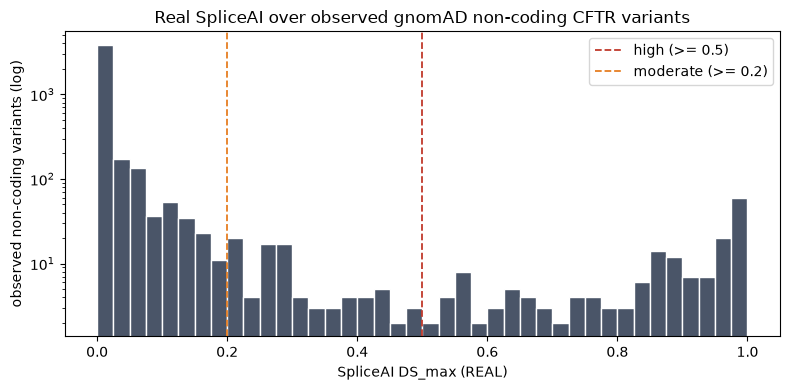

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(worklist["spliceai_ds_max"], bins=40, color="#4a5568", edgecolor="white")
ax.axvline(0.5, ls="--", color="#c0392b", lw=1.3, label="high (>= 0.5)")
ax.axvline(0.2, ls="--", color="#e67e22", lw=1.3, label="moderate (>= 0.2)")
ax.set_yscale("log")
ax.set_xlabel("SpliceAI DS_max (REAL)"); ax.set_ylabel("observed non-coding variants (log)")
ax.set_title("Real SpliceAI over observed gnomAD non-coding CFTR variants")
ax.legend(); fig.tight_layout(); plt.show()

## 7 · Key takeaways

1. **SpliceAI is REAL** — 2,075,730 CFTR records (Illumina v1.3), `source == REAL`:
   566,106 SNVs **plus** 1,509,624 indels, all masked.
2. **Read the four deltas, not just DS_max.** The deltas are the model's actual output
   and are all kept; `spliceai_ds_max` is only their maximum, so the collapse is always
   reversible. A high `DS_DL` and a high `DS_AG` are different biology at the same score.
3. **Indels are included**, which matters more than the row count suggests: no missense
   predictor can score an indel, so these are variants that would otherwise have *no*
   prediction from anything. F508del scores **DS_max 0.00** — correctly, it is a folding
   defect, not a splice one.
4. **Masking is an annotation filter, not a different model.** It zeroes gains at real
   splice sites and losses at non-sites, all-or-nothing, and `raw >= masked` always.
   Measured over all four downloaded files: DS_max agrees exactly on **95.48%** of the
   2,075,730 records, **450** cross the 0.5 cut, but that is **one** variant in the
   observed worklist and **none** of the 1,728 scored CFTR2 variants. Masked, per
   Illumina's advice for variant interpretation.
5. The **real splice worklist**: **4,535** of the 4,717 observed non-coding CFTR variants
   scored, **173 HIGH** and 86 MODERATE. The SNV-only subset of that same join is 4,260
   scored / 164 HIGH; the rest is what the indel file adds.
6. **Join on authoritative coordinates, and count what came back.** A wrong coordinate
   returns nothing rather than an error, and nothing is indistinguishable from a real
   negative — the quietest way to be wrong here.
7. **A low `DS_max` is not evidence of no splice effect.** `3849+10kb C>T` is in the
   extract and scores just 0.16, and not for any of the usual excuses: it is 2,477 nt
   from the nearest exon (the "10 kb" counts from the other end of the intron), and the
   donor gain SpliceAI predicts for it sits 2 nt away, well inside the ±50 nt reporting
   window. The model finds the site and rates it low. That is a false negative on a
   CF-causing allele, and the reason this notebook is a worklist rather than a verdict.
8. **Version** comes from the VCFs' own headers, persisted to a `.release.json` sidecar
   and exposed as `spliceai_release` — the release's claim about itself, not a download date.
9. Scores are **CC BY-NC 4.0** — cite SpliceAI/Illumina; keep the source VCFs external.

**Next:** tools/08 — **Pangolin**, the independent splice model, run locally.